In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import mne

root = mne.datasets.sample.data_path() / "MEG" / "sample"
raw_file = root / "sample_audvis_filt-0-40_raw.fif"
raw = mne.io.read_raw_fif(raw_file, preload=False)

events_file = root / "sample_audvis_filt-0-40_raw-eve.fif"
events = mne.read_events(events_file)

raw.crop(tmax=90)  # in seconds (happens in-place)
# discard events >90 seconds (not strictly necessary, but avoids some warnings)
events = events[events[:, 0] <= raw.last_samp]

Using default location ~/mne_data for sample...


100%|█████████████████████████████████████| 1.65G/1.65G [00:00<00:00, 18.0GB/s]
Untarring contents of '/root/mne_data/MNE-sample-data-processed.tar.gz' to '/root/mne_data'


Download complete in 13m01s (1576.2 MB)
Opening raw data file /root/mne_data/MNE-sample-data/MEG/sample/sample_audvis_filt-0-40_raw.fif...
    Read a total of 4 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
        Average EEG reference (1 x 60)  idle
    Range : 6450 ... 48149 =     42.956 ...   320.665 secs
Ready.


In [2]:
raw.pick(["eeg", "eog"]).load_data()
raw.info

Reading 0 ... 13514  =      0.000 ...    90.001 secs...


<Info | 15 non-empty values
 bads: 1 items (EEG 053)
 ch_names: EEG 001, EEG 002, EEG 003, EEG 004, EEG 005, EEG 006, EEG 007, ...
 chs: 60 EEG, 1 EOG
 custom_ref_applied: False
 dev_head_t: MEG device -> head transform
 dig: 146 items (3 Cardinal, 4 HPI, 61 EEG, 78 Extra)
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 lowpass: 40.0 Hz
 meas_date: 2002-12-03 19:01:10 UTC
 meas_id: 4 items (dict)
 nchan: 61
 projs: Average EEG reference: off
 sfreq: 150.2 Hz
>

In [4]:
channel_renaming_dict = {name: name.replace(" 0", "").lower() for name in raw.ch_names}
_ = raw.rename_channels(channel_renaming_dict)  # happens in-place

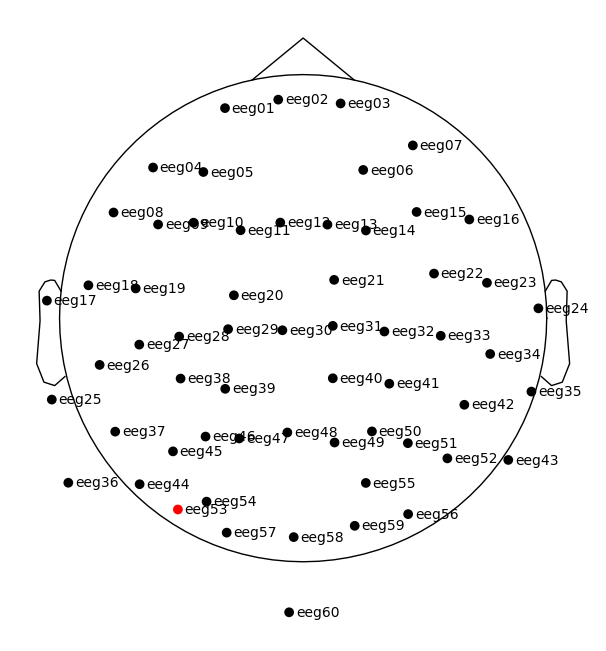

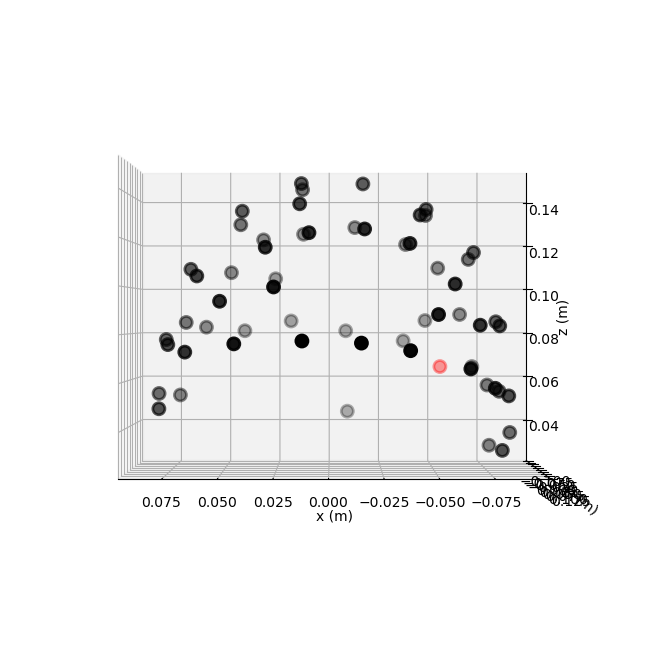

In [5]:
raw.plot_sensors(show_names=True)
fig = raw.plot_sensors("3d")

Using matplotlib as 2D backend.


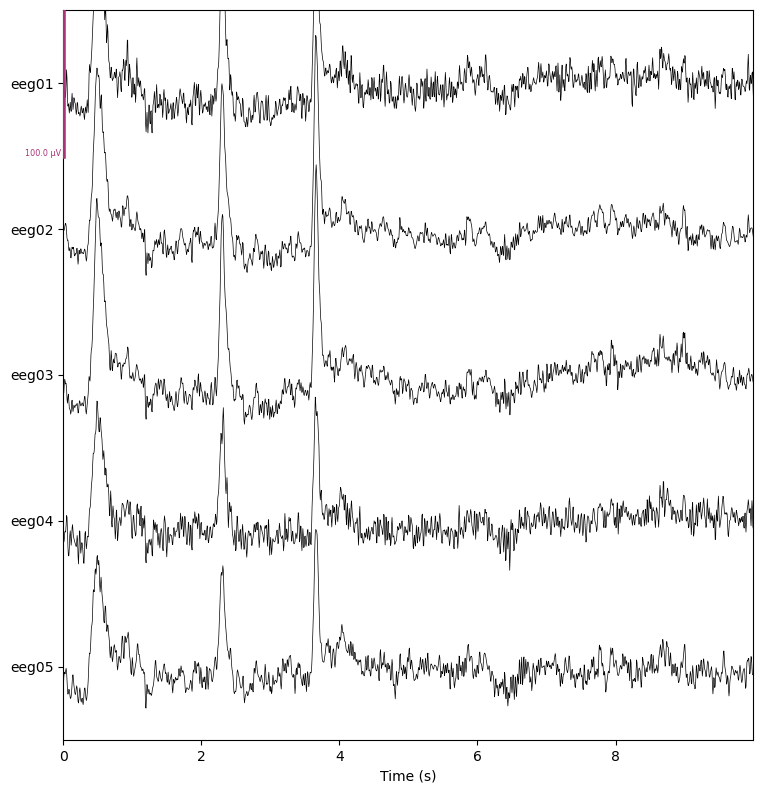

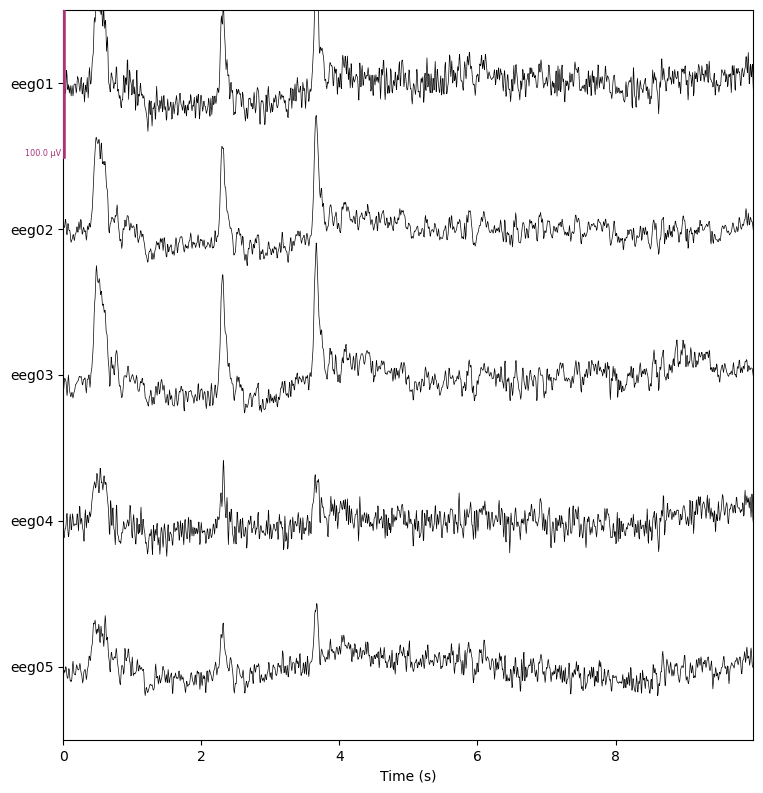

In [6]:
for proj in (False, True):
    with mne.viz.use_browser_backend("matplotlib"):
        fig = raw.plot(
            n_channels=5, proj=proj, scalings=dict(eeg=50e-6), show_scrollbars=False
        )
    fig.subplots_adjust(top=0.9)  # make room for title
    ref = "Average" if proj else "No"
    fig.suptitle(f"{ref} reference", size="xx-large", weight="bold")

In [7]:
raw.filter(l_freq=0.1, h_freq=None)

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 0.1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Filter length: 4957 samples (33.013 s)



<Raw | sample_audvis_filt-0-40_raw.fif, 61 x 13515 (90.0 s), ~9.2 MiB, data loaded>

In [8]:
np.unique(events[:, -1])

array([ 1,  2,  3,  4,  5, 32])

In [9]:
event_dict = {
    "auditory/left": 1,
    "auditory/right": 2,
    "visual/left": 3,
    "visual/right": 4,
    "face": 5,
    "buttonpress": 32,
}

Not setting metadata
132 matching events found
Setting baseline interval to [-0.2996928197375818, 0.0] s
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Using data from preloaded Raw for 132 events and 151 original time points ...
1 bad epochs dropped
You seem to have overlapping epochs. Some event lines may be duplicated in the plot.


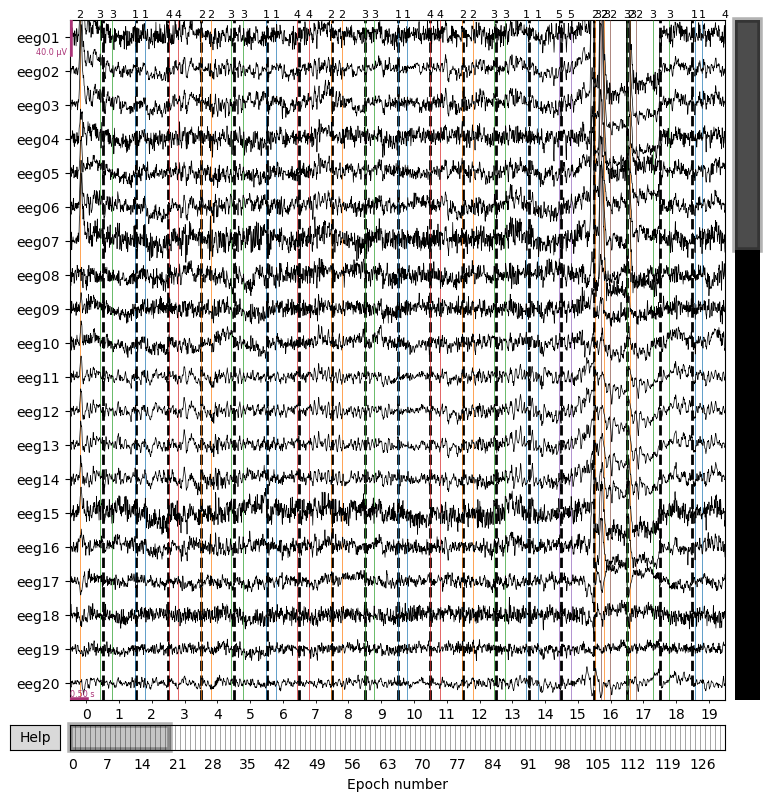

In [10]:
epochs = mne.Epochs(raw, events, event_id=event_dict, tmin=-0.3, tmax=0.7, preload=True)
fig = epochs.plot(events=events)

In [11]:
reject_criteria = dict(eeg=100e-6, eog=200e-6)  # 100 µV, 200 µV
epochs.drop_bad(reject=reject_criteria)

    Rejecting  epoch based on EEG : ['eeg03']
    Rejecting  epoch based on EEG : ['eeg01', 'eeg02', 'eeg03', 'eeg04', 'eeg06', 'eeg07']
    Rejecting  epoch based on EEG : ['eeg01', 'eeg02', 'eeg03', 'eeg04', 'eeg06', 'eeg07']
    Rejecting  epoch based on EEG : ['eeg01', 'eeg02', 'eeg03', 'eeg04', 'eeg06', 'eeg07']
    Rejecting  epoch based on EEG : ['eeg01', 'eeg02', 'eeg03', 'eeg07']
    Rejecting  epoch based on EEG : ['eeg01', 'eeg02', 'eeg03', 'eeg07']
    Rejecting  epoch based on EEG : ['eeg01']
    Rejecting  epoch based on EEG : ['eeg03', 'eeg07']
    Rejecting  epoch based on EEG : ['eeg03', 'eeg07']
    Rejecting  epoch based on EEG : ['eeg07']
    Rejecting  epoch based on EEG : ['eeg03', 'eeg07']
    Rejecting  epoch based on EEG : ['eeg03', 'eeg07']
    Rejecting  epoch based on EEG : ['eeg07']
    Rejecting  epoch based on EEG : ['eeg07']
    Rejecting  epoch based on EEG : ['eeg03']
    Rejecting  epoch based on EEG : ['eeg25']
    Rejecting  epoch based on EEG : ['e

<Epochs | 114 events (all good), -0.3 – 0.699 s (baseline -0.3 – 0 s), ~10.9 MiB, data loaded,
 'auditory/left': 25
 'auditory/right': 27
 'visual/left': 28
 'visual/right': 25
 'face': 5
 'buttonpress': 4>

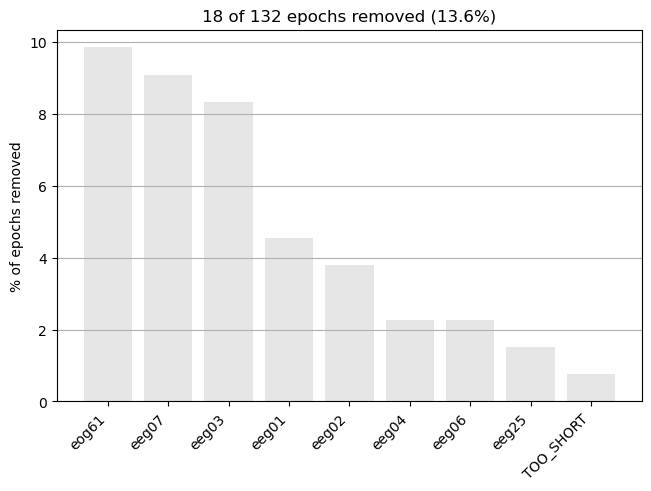

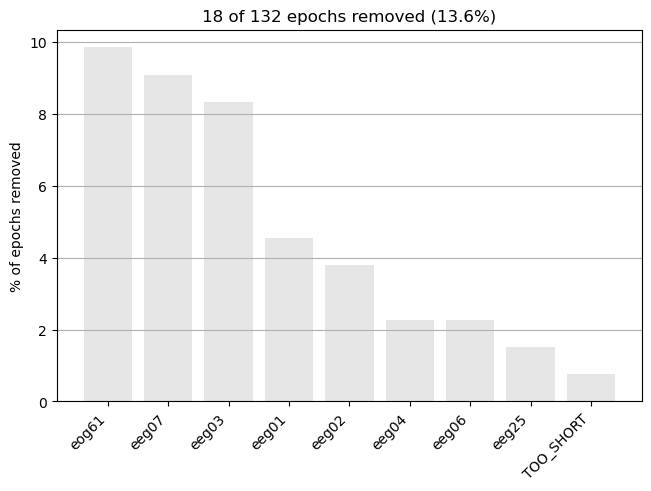

In [12]:
epochs.plot_drop_log()

In [13]:
l_aud = epochs["auditory/left"].average()
l_vis = epochs["visual/left"].average()

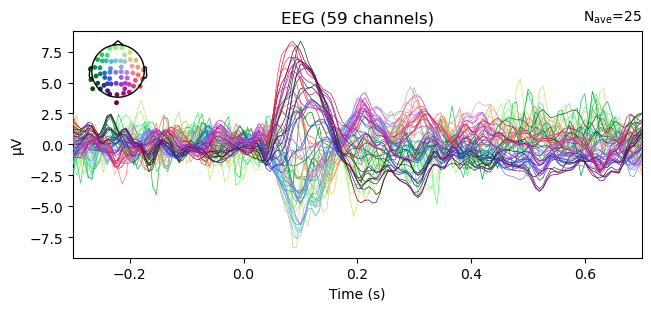

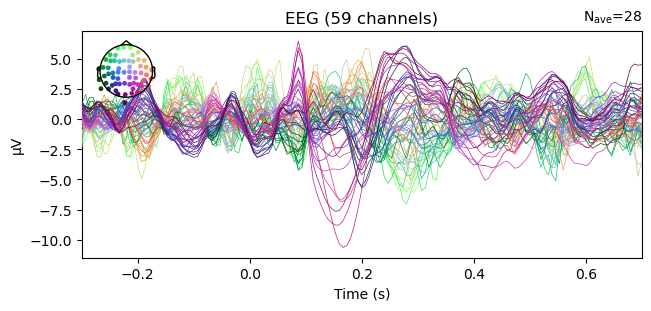

In [14]:
fig1 = l_aud.plot()
fig2 = l_vis.plot(spatial_colors=True)

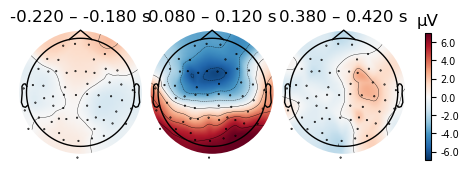

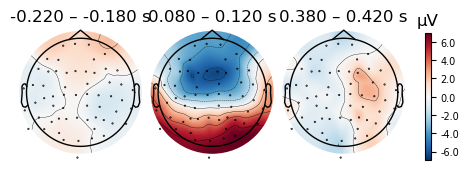

In [15]:
l_aud.plot_topomap(times=[-0.2, 0.1, 0.4], average=0.05)

Projections have already been applied. Setting proj attribute to True.


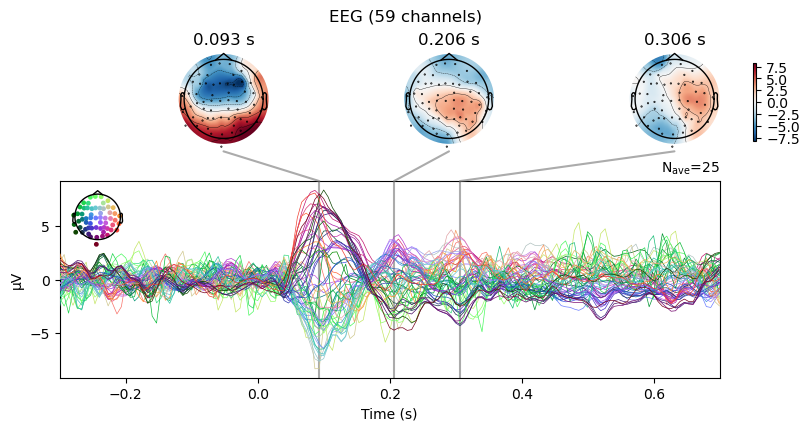

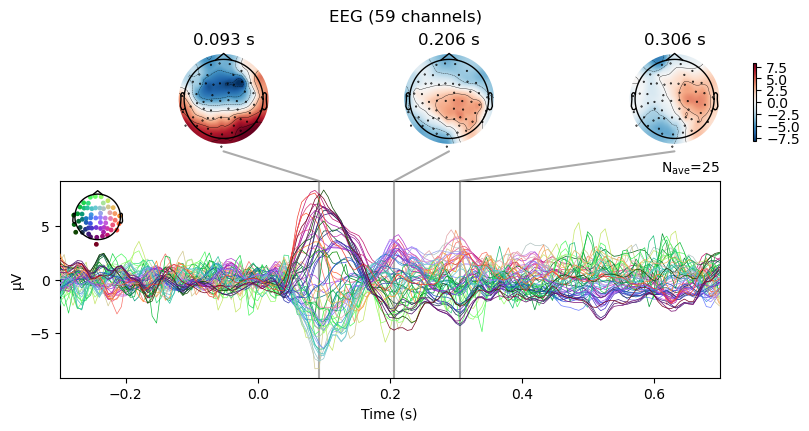

In [16]:
l_aud.plot_joint()

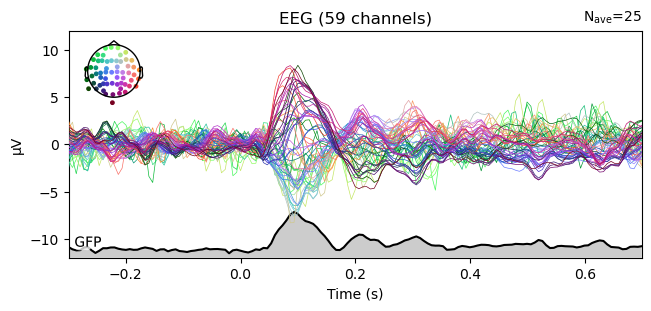

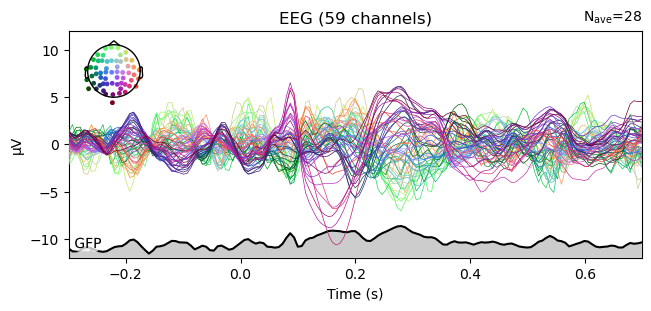

In [17]:
for evk in (l_aud, l_vis):
    evk.plot(gfp=True, spatial_colors=True, ylim=dict(eeg=[-12, 12]))

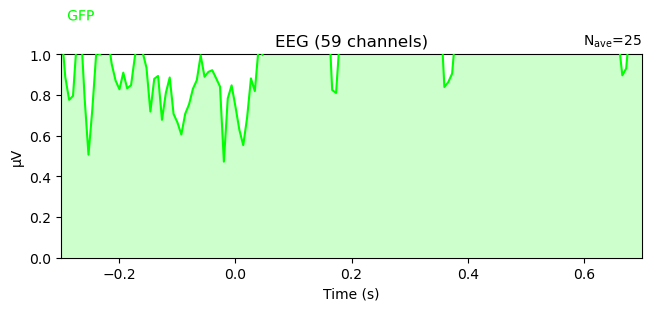

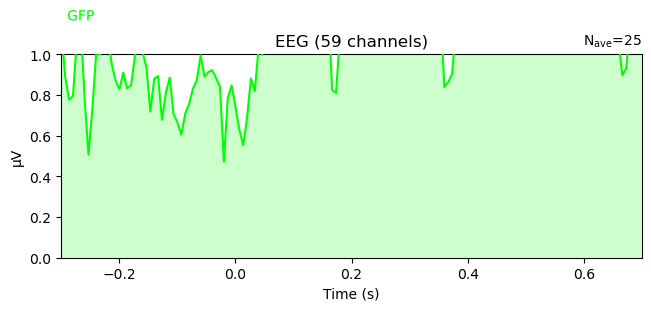

In [18]:
l_aud.plot(gfp="only")

[Text(0.5, 0, 'Time (s)'), Text(0, 0.5, 'GFP (µV)'), Text(0.5, 1.0, 'EEG')]

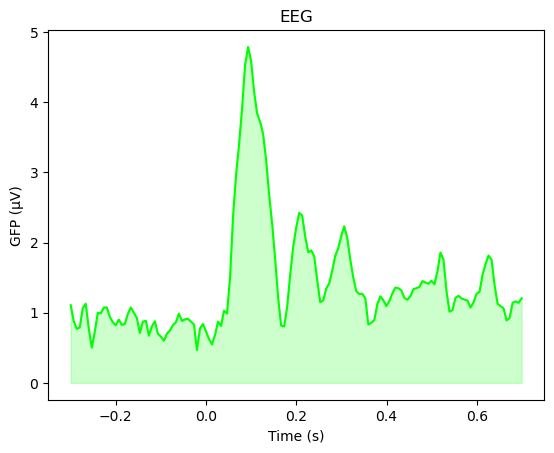

In [19]:
gfp = l_aud.data.std(axis=0, ddof=0)

# Reproducing the MNE-Python plot style seen above
fig, ax = plt.subplots()
ax.plot(l_aud.times, gfp * 1e6, color="lime")
ax.fill_between(l_aud.times, gfp * 1e6, color="lime", alpha=0.2)
ax.set(xlabel="Time (s)", ylabel="GFP (µV)", title="EEG")

In [20]:
left = ["eeg17", "eeg18", "eeg25", "eeg26"]
right = ["eeg23", "eeg24", "eeg34", "eeg35"]

left_ix = mne.pick_channels(l_aud.info["ch_names"], include=left)
right_ix = mne.pick_channels(l_aud.info["ch_names"], include=right)

Applying baseline correction (mode: mean)
['left_ROI', 'right_ROI']


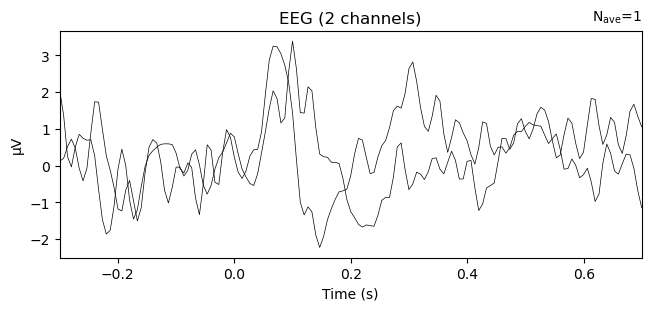

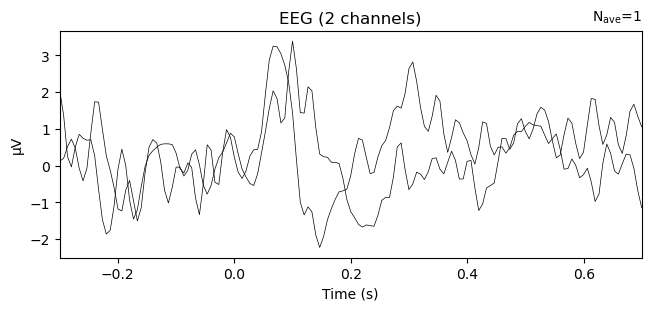

In [21]:
roi_dict = dict(left_ROI=left_ix, right_ROI=right_ix)
roi_evoked = mne.channels.combine_channels(l_aud, roi_dict, method="mean")
print(roi_evoked.info["ch_names"])
roi_evoked.plot()

In [22]:
evokeds = dict(
    auditory=list(epochs["auditory/left"].iter_evoked()),
    visual=list(epochs["visual/left"].iter_evoked()),
)
mne.viz.plot_compare_evokeds(evokeds, combine="mean", picks=picks)

NameError: name 'picks' is not defined

In [ ]:
aud_minus_vis = mne.combine_evoked([l_aud, l_vis], weights=[1, -1])
aud_minus_vis.plot_joint()

In [ ]:
grand_average = mne.grand_average([l_aud, l_vis])
print(grand_average)

In [ ]:
list(event_dict)

In [ ]:
epochs["auditory"].average()

In [ ]:
# Define a function to print out the channel (ch) containing the
# peak latency (lat; in msec) and amplitude (amp, in µV), with the
# time range (tmin and tmax) that was searched.
# This function will be used throughout the remainder of the tutorial.
def print_peak_measures(ch, tmin, tmax, lat, amp):
    print(f"Channel: {ch}")
    print(f"Time Window: {tmin * 1e3:.3f} - {tmax * 1e3:.3f} ms")
    print(f"Peak Latency: {lat * 1e3:.3f} ms")
    print(f"Peak Amplitude: {amp * 1e6:.3f} µV")


# Get peak amplitude and latency from a good time window that contains the peak
good_tmin, good_tmax = 0.08, 0.12
ch, lat, amp = l_vis.get_peak(
    ch_type="eeg", tmin=good_tmin, tmax=good_tmax, mode="pos", return_amplitude=True
)

# Print output from the good time window that contains the peak
print("** PEAK MEASURES FROM A GOOD TIME WINDOW **")
print_peak_measures(ch, good_tmin, good_tmax, lat, amp)

In [ ]:
# Fist, return a copy of l_vis to select the channel from
l_vis_roi = l_vis.copy().pick("eeg59")

# Get the peak and latency measure from the selected channel
ch_roi, lat_roi, amp_roi = l_vis_roi.get_peak(
    tmin=good_tmin, tmax=good_tmax, mode="pos", return_amplitude=True
)

# Print output
print("** PEAK MEASURES FOR ONE CHANNEL FROM A GOOD TIME WINDOW **")
print_peak_measures(ch_roi, good_tmin, good_tmax, lat_roi, amp_roi)

In [ ]:
# Get BAD peak measures
bad_tmin, bad_tmax = 0.095, 0.135
ch_roi, bad_lat_roi, bad_amp_roi = l_vis_roi.get_peak(
    mode="pos", tmin=bad_tmin, tmax=bad_tmax, return_amplitude=True
)

# Print output
print("** PEAK MEASURES FOR ONE CHANNEL FROM A BAD TIME WINDOW **")
print_peak_measures(ch_roi, bad_tmin, bad_tmax, bad_lat_roi, bad_amp_roi)

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=1, layout="tight")
words = (("Bad", "missing"), ("Good", "finding"))
times = (np.array([bad_tmin, bad_tmax]), np.array([good_tmin, good_tmax]))
colors = ("C1", "C0")

for ix, ax in enumerate(axs):
    title = "{} time window {} peak".format(*words[ix])
    l_vis_roi.plot(axes=ax, time_unit="ms", show=False, titles=title)
    ax.plot(lat_roi * 1e3, amp_roi * 1e6, marker="*", color="C6")
    ax.axvspan(*(times[ix] * 1e3), facecolor=colors[ix], alpha=0.3)
    ax.set_xlim(-50, 150)  # Show zoomed in around peak

In [ ]:
# Select all of the channels and crop to the time window
channels = ["eeg54", "eeg57", "eeg55", "eeg59"]
hemisphere = ["left", "left", "right", "right"]
l_vis_mean_roi = l_vis.copy().pick(channels).crop(tmin=good_tmin, tmax=good_tmax)

# Extract mean amplitude in µV over time
mean_amp_roi = l_vis_mean_roi.data.mean(axis=1) * 1e6

# Store the data in a data frame
mean_amp_roi_df = pd.DataFrame(
    {
        "ch_name": l_vis_mean_roi.ch_names,
        "hemisphere": ["left", "left", "right", "right"],
        "mean_amp": mean_amp_roi,
    }
)

# Print the data frame
print(mean_amp_roi_df.groupby("hemisphere").mean(numeric_only=True))

In [ ]:
# Extract mean amplitude for all channels in l_vis (including `eog`)
l_vis_cropped = l_vis.copy().crop(tmin=good_tmin, tmax=good_tmax)
mean_amp_all = l_vis_cropped.data.mean(axis=1) * 1e6
mean_amp_all_df = pd.DataFrame(
    {"ch_name": l_vis_cropped.info["ch_names"], "mean_amp": mean_amp_all}
)
mean_amp_all_df["tmin"] = good_tmin
mean_amp_all_df["tmax"] = good_tmax
mean_amp_all_df["condition"] = "Left/Visual"
with pd.option_context("display.max_columns", None):
    print(mean_amp_all_df.head())
    print(mean_amp_all_df.tail())